In [34]:
# import packages
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.nn import functional as F
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

In [3]:
# verify PyTorch installation
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [4]:
# define transformations
transform = transforms.ToTensor()

In [5]:
# load MNIST train dataset
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

# load MNIST test dataset
test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

In [6]:
# create dataLoaders (batches)
batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 938
Testing batches: 157


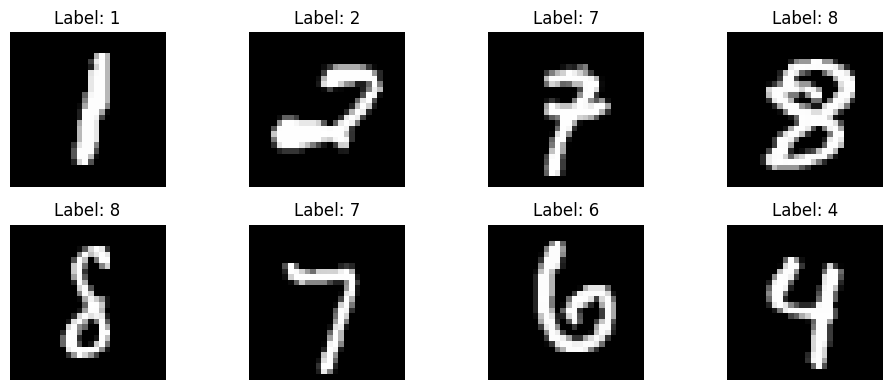

In [7]:
# visualize sample digits
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# build neural network: ully connected neural network (MLP)
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MNISTClassifier()
print(model)

MNISTClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [16]:
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
# set same device for model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cpu


In [18]:
# define function for training blocks
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [19]:
# define evaluate function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# train model
epochs = 5

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss:  {test_loss:.4f} | Test Accuracy:  {test_acc:.4f}")
    print("-" * 50)

Epoch [1/5]
Train Loss: 0.3407 | Train Accuracy: 0.9043
Test Loss:  0.1784 | Test Accuracy:  0.9483
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.1424 | Train Accuracy: 0.9581
Test Loss:  0.1275 | Test Accuracy:  0.9622
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.0979 | Train Accuracy: 0.9702
Test Loss:  0.0980 | Test Accuracy:  0.9699
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.0734 | Train Accuracy: 0.9779
Test Loss:  0.0945 | Test Accuracy:  0.9707
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.0575 | Train Accuracy: 0.9828
Test Loss:  0.0787 | Test Accuracy:  0.9750
--------------------------------------------------


Model architecture (MLP with 28×28→128→64→10)
Training setup (epochs, batch size, optimizer, learning rate)
Final test accuracy (e.g., 97.5%) with a short interpretation.

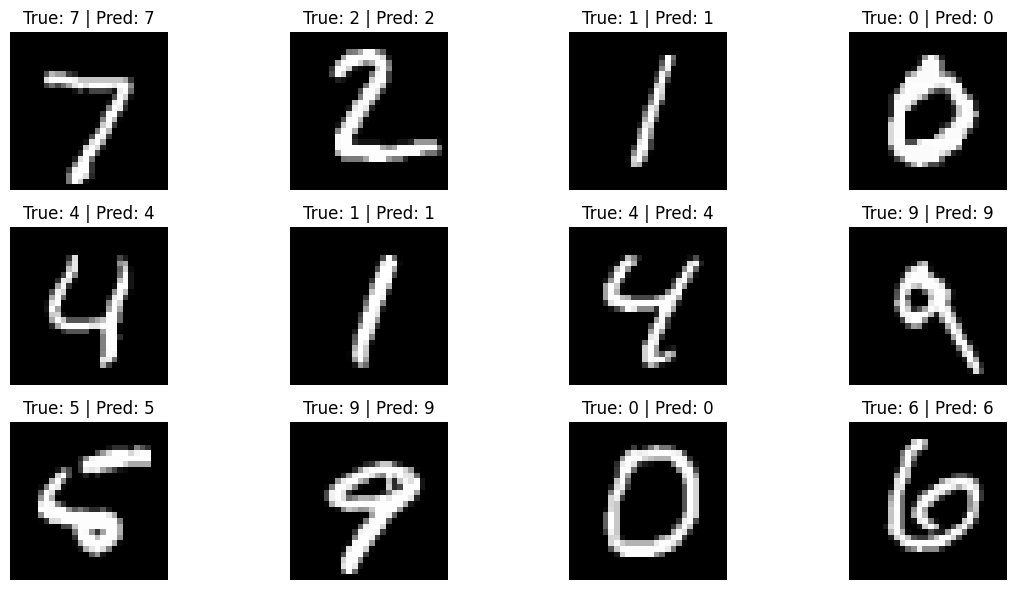

In [ ]:
# visualize model predictions for correct predictions
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(f"True: {labels[i].item()} | Pred: {predictions[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

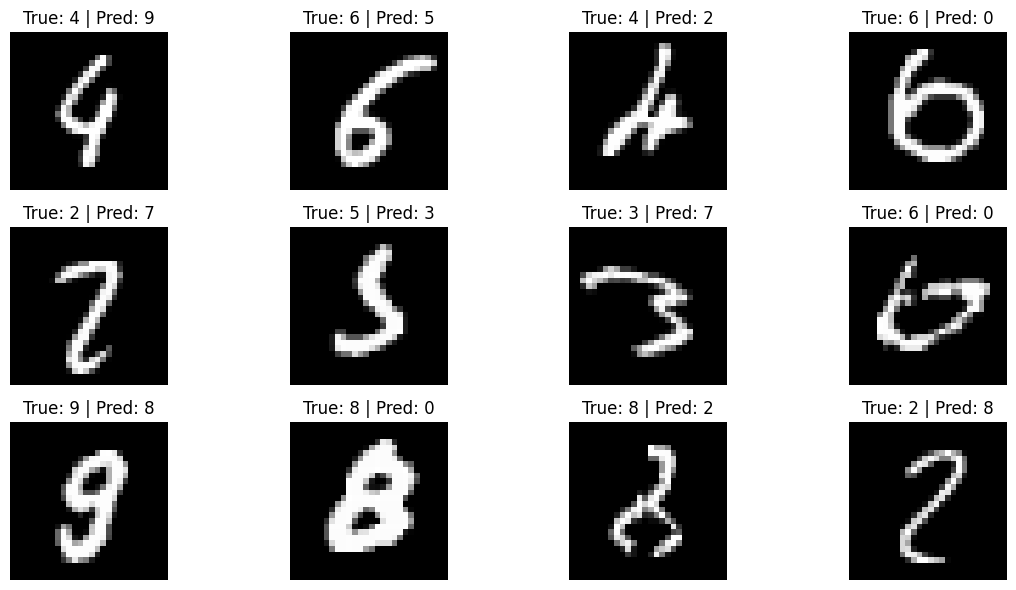

In [27]:
# visualize model predictions for wrong predictions
incorrect_images = []
incorrect_labels = []
incorrect_preds = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        incorrect_mask = preds != labels

        incorrect_images.extend(images[incorrect_mask].cpu())
        incorrect_labels.extend(labels[incorrect_mask].cpu())
        incorrect_preds.extend(preds[incorrect_mask].cpu())

        if len(incorrect_images) >= 12:
            break

plt.figure(figsize=(12, 6))

for i in range(min(12, len(incorrect_images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(incorrect_images[i].squeeze(), cmap="gray")
    plt.title(f"True: {incorrect_labels[i].item()} | Pred: {incorrect_preds[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

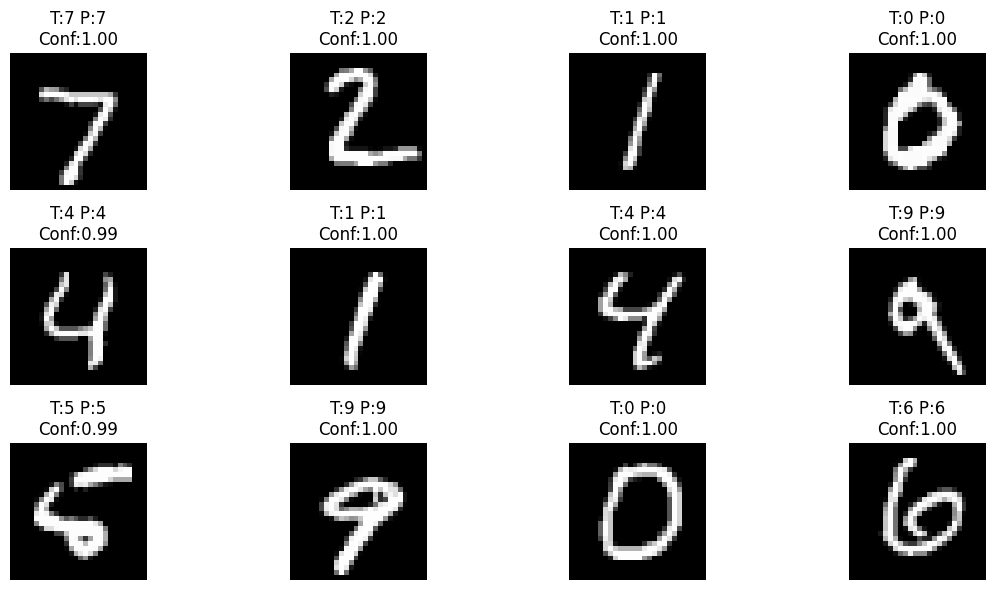

In [ ]:
# get confidence scores for correct model predictions
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    probabilities = torch.softmax(outputs, dim=1)
    confidences, predictions = torch.max(probabilities, dim=1)

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(
        f"T:{labels[i].item()} P:{predictions[i].item()}\nConf:{confidences[i].item():.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

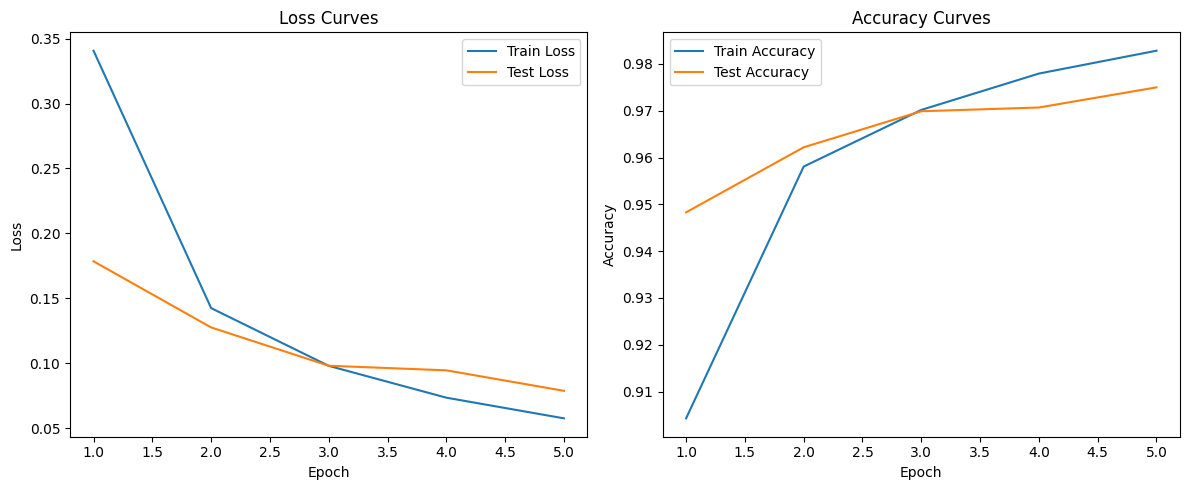

In [37]:
# plot learning curves
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

Loss curves:
Both train loss and test loss decrease steadily with epoch, which means the optimization is working and the model is fitting patterns in the data rather than getting stuck.

Test loss is slightly below or close to train loss early on, then stays close but a bit higher later, which is normal: the model does best on the data it saw during training, but still performs strongly on unseen test data.

There’s no point where test loss starts going back up sharply while train loss keeps going down, which would be a classic overfitting signal.

Accuracy curves:
Both train accuracy and test accuracy rise and then flatten out around 97–98%, which is exactly what you expect for this simple MLP on MNIST.

The curves are very close to each other; the gap between them is small. That means the model’s performance on unseen data is almost as good as on training data → good generalization.

There’s no divergence where train accuracy keeps climbing while test accuracy stalls or drops; that would be another overfitting signal.

In [ ]:
# generate confusion matrix
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix shape:", cm.shape)
cm

Confusion matrix shape: (10, 10)


array([[ 972,    0,    0,    0,    1,    0,    1,    1,    3,    2],
       [   0, 1116,    3,    2,    0,    0,    2,    0,   12,    0],
       [   8,    2,  993,    3,    2,    0,    3,    5,   16,    0],
       [   1,    0,    5,  984,    0,    5,    0,    6,    5,    4],
       [   1,    0,    3,    0,  957,    0,    1,    1,    1,   18],
       [   3,    0,    0,    8,    1,  869,    2,    1,    6,    2],
       [   7,    1,    0,    1,    4,    6,  935,    0,    4,    0],
       [   2,    3,    8,    5,    1,    0,    0,  992,    4,   13],
       [   5,    0,    1,    2,    4,    2,    2,    2,  950,    6],
       [   3,    3,    0,    3,    7,    2,    0,    6,    3,  982]])

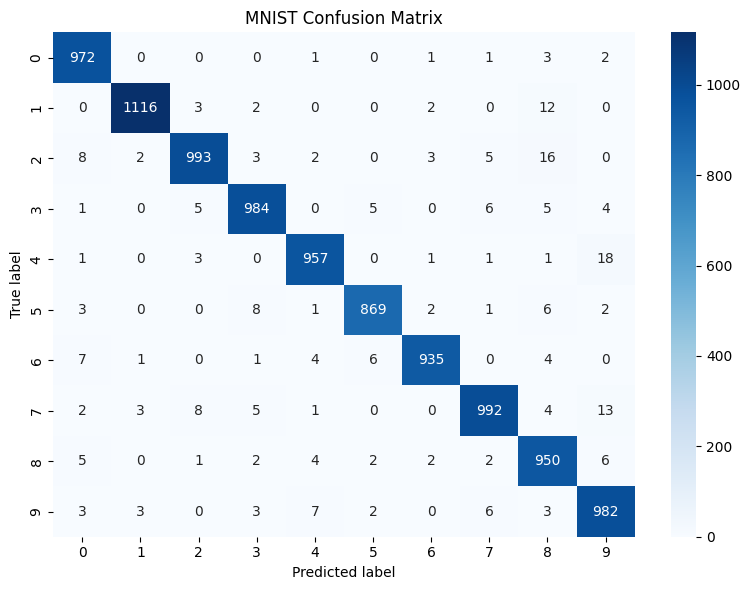

In [35]:
# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10))
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("MNIST Confusion Matrix")
plt.tight_layout()
plt.show()

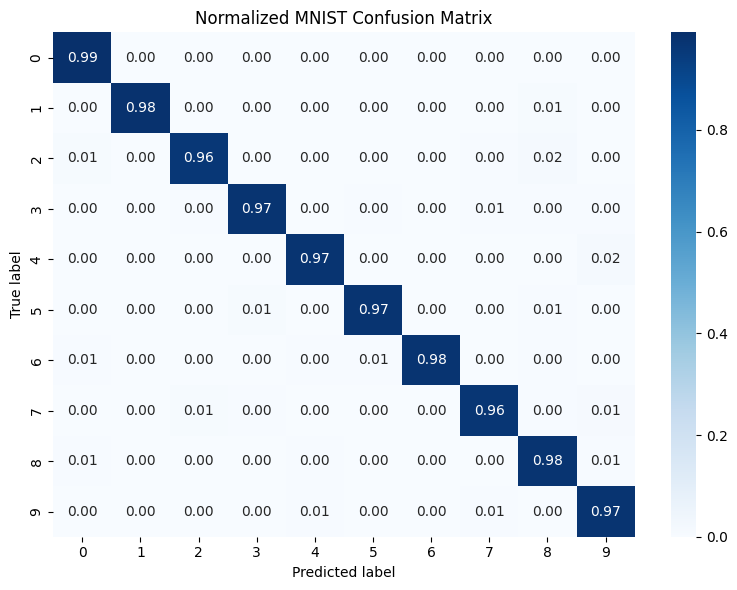

In [36]:
# visualize confusion matrix as percentages
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10)),
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized MNIST Confusion Matrix")
plt.tight_layout()
plt.show()

Output Summary:
There is no obvious class bias: each digit has strong diagonal counts, so the model is not ignoring any one digit.

The errors are semantically reasonable: they mostly happen between digits that humans also confuse (4 vs 9, 3 vs 5, etc.), not random mismatches like 1 vs 8 everywhere.

With a simple MLP and only 5 epochs, this pattern is exactly what you’d expect from a solid MNIST baseline; moving to a CNN would likely shrink those off‑diagonal mistakes further if you wanted to push accuracy even higher.